<a href="https://colab.research.google.com/github/noufalshehri/OCCUPATIONAL-BURNOUT-RATE-PREDICTION/blob/main/OBP_Modelling_with_all_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#for data processing
import pandas as pd
import numpy as np
#for modelling:
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate,LeaveOneOut
#for plotting
from matplotlib import pyplot as plt
import seaborn as sns
# for measuring accuracy
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error

In [ ]:
# Load the dataset
df_rate = pd.read_csv('OBP_preprocess.csv')
df_rate

,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,5538,1,1,0,2,3,3.8,0.16
1,5477,0,1,1,1,2,5.0,0.36
2,5504,0,1,1,1,1,2.6,0.20
3,5606,1,1,0,3,7,6.9,0.52
4,5481,0,0,1,2,4,3.6,0.29
...,...,...,...,...,...,...,...,...
18585,5462,1,0,1,1,3,6.0,0.48
18586,5664,0,0,0,3,7,6.2,0.54
18587,5793,1,0,1,3,6,6.7,0.59
18588,5802,1,1,0,2,5,5.9,0.52


In [ ]:
x = df_rate.iloc[:,:-1]
y = df_rate.iloc[:,-1]
x.shape

(18590, 7)

In [ ]:
y.shape

(18590,)

In [ ]:
#split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=101)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13942, 7)
(4648, 7)
(13942,)
(4648,)


In [ ]:
#to store all the algorithms' accuracy score:
all_accuracy=[]
#to store all the algorithms' mean squared error:
all_mse=[]

##Linear Regression

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)
linear_accuracy=regressor.score(X_test, y_test)
y_pred=regressor.predict(X_test)
all_accuracy.append(linear_accuracy)
LR_MSE=mean_squared_error(y_test,y_pred)
all_mse.append(LR_MSE)
print("Accuracy: ",linear_accuracy)
print("MSE: ",LR_MSE)

Accuracy:  0.9221362003416339
MSE:  0.00311610795697527


##Ploynomial Linear Regression

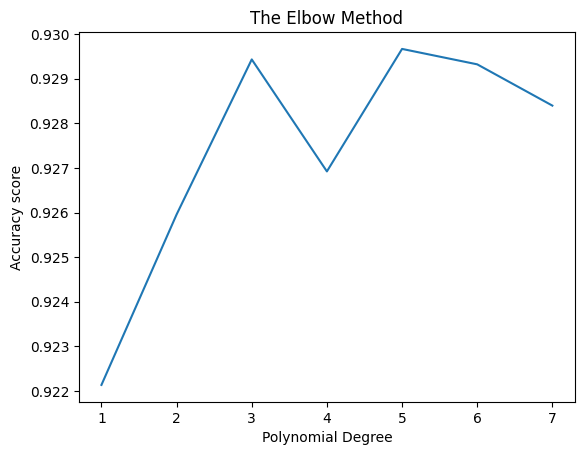

Accuracy:  0.9296662665507732
MSE:  0.002814754833523783


In [ ]:
accuracy = []
mse=[]
for i in range(1, 8):
  poly_reg = PolynomialFeatures(degree=i)
  X_poly= poly_reg.fit_transform(X_train)
  regressor = LinearRegression()
  regressor.fit(X_poly, y_train)
  y_pred=regressor.predict(poly_reg.fit_transform(X_test))
  mse.append(y_pred)
  accuracy_S =r2_score(y_test,y_pred)
  accuracy.append(accuracy_S)

plt.plot(range(1, 8), accuracy)
plt.title('The Elbow Method')
plt.xlabel('Polynomial Degree')
plt.ylabel('Accuracy score')
plt.show()


Poly_accuracy=max(accuracy)
index=accuracy.index(Poly_accuracy)
all_accuracy.append(Poly_accuracy)
poly_MSE=mean_squared_error(y_test,mse[index])
all_mse.append(poly_MSE)
print("Accuracy: ",Poly_accuracy)
print("MSE: ",poly_MSE)

##Decision Tree Regression

In [ ]:
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X_train, y_train)
y_pred=regressor.predict(X_test)
DTR_accuracy = regressor.score(X_test,y_test)
all_accuracy.append(DTR_accuracy)
dtr_MSE=mean_squared_error(y_test,y_pred)
all_mse.append(dtr_MSE)
print("Accuracy: ",DTR_accuracy)
print("MSE: ",dtr_MSE)

Accuracy:  0.8599104789711033
MSE:  0.005606380283036909


## Random Forest Regression

Accuracy:  0.9199894173259201
MSE:  0.003202022177274259


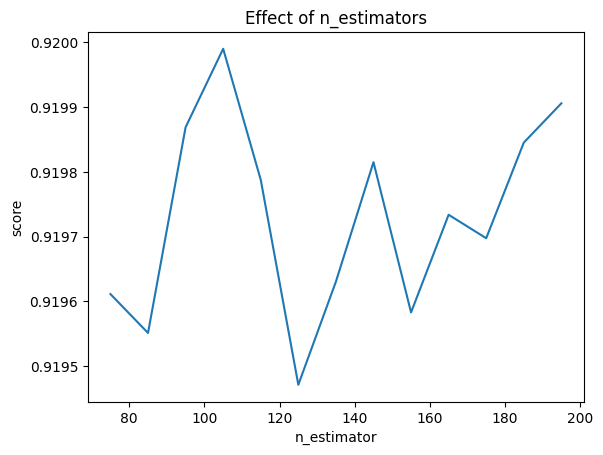

In [ ]:
RFR = RandomForestRegressor()
# Try different numbers of n_estimators using the elbow method to pick the best
estimators = np.arange(75, 200 , 10)
scores = []
mse=[]
for n in estimators:
    RFR.set_params(n_estimators=n)
    RFR.fit(X_train, y_train)
    scores.append(RFR.score(X_test, y_test))
    y_pred=RFR.predict(X_test)
    mse.append(y_pred)
plt.title("Effect of n_estimators")
plt.xlabel("n_estimator")
plt.ylabel("score")
plt.plot(estimators, scores)
RFR_accuracy=max(scores)
index=scores.index(RFR_accuracy)
all_accuracy.append(RFR_accuracy)
RFR_MSE=mean_squared_error(y_test,mse[index])
all_mse.append(RFR_MSE)
print("Accuracy: ",RFR_accuracy)
print("MSE: ",RFR_MSE)

##Ridge Regression

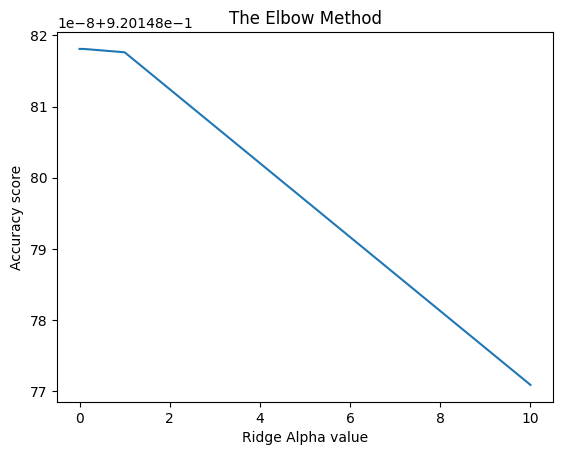

Accuracy:  0.9201488181082992
MSE:  0.0031161079577847806


In [ ]:
accuracy = []
mse=[]
alphas=[0.0001, 0.001,0.01, 0.1, 1, 10]
for i in alphas:
  RR = Ridge(alpha = i)
  RR.fit(X_train,y_train)
  y_pred=RR.predict(X_test)
  mse.append(y_pred)
  accuracy_S =RR.score(X_train,y_train)
  accuracy.append(accuracy_S)

plt.plot(alphas, accuracy)
plt.title('The Elbow Method')
plt.xlabel('Ridge Alpha value')
plt.ylabel('Accuracy score')
plt.show()


RR_accuracy=max(accuracy)
index=accuracy.index(RR_accuracy)
all_accuracy.append(RR_accuracy)
RR_MSE=mean_squared_error(y_test,mse[index])
all_mse.append(RR_MSE)
print("Accuracy: ",RR_accuracy)
print("MSE: ",RR_MSE)

##Lacco Regression

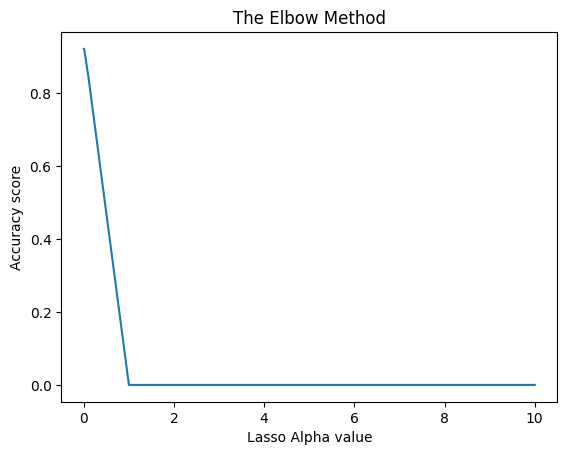

Accuracy:  0.9201447896529881
MSE:  0.003116984111433995


In [ ]:
accuracy = []
mse=[]
alphas=[0.0001, 0.001,0.01, 0.1, 1, 10]
for i in alphas:
  lasso = Lasso(alpha = i)
  lasso.fit(X_train,y_train)
  y_pred=lasso.predict(X_test)
  mse.append(y_pred)
  accuracy_S =lasso.score(X_train,y_train)
  accuracy.append(accuracy_S)

plt.plot(alphas, accuracy)
plt.title('The Elbow Method')
plt.xlabel('Lasso Alpha value')
plt.ylabel('Accuracy score')
plt.show()


lasso_accuracy=max(accuracy)
index=accuracy.index(lasso_accuracy)
all_accuracy.append(lasso_accuracy)
lasso_MSE=mean_squared_error(y_test,mse[index])
all_mse.append(lasso_MSE)
print("Accuracy: ",lasso_accuracy)
print("MSE: ",lasso_MSE)

##K Nearest Neighbour Regression

Accuracy:  0.8912500385780624
MSE:  0.004352171632960413


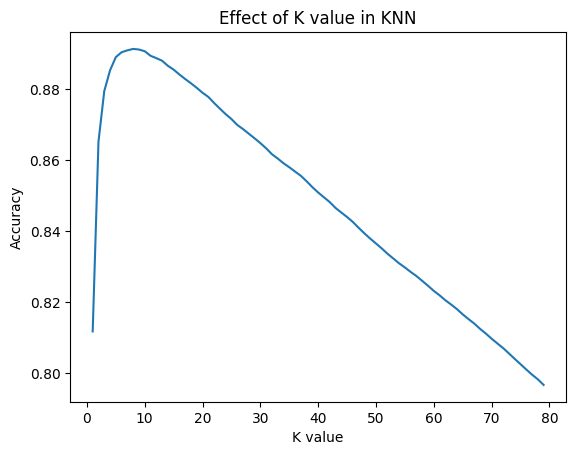

In [ ]:
mse=[]
k_list=np.arange(1,80,1)
accuracy=[]
for i in k_list:
    knn=KNeighborsRegressor(n_neighbors=int(i))
    model_knn=knn.fit(X_train,y_train)
    y_knn_pred=model_knn.predict(X_test)
    mse.append(y_knn_pred)
    accuracy_S =r2_score(y_test, y_knn_pred)
    accuracy.append(accuracy_S)

plt.title("Effect of K value in KNN")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.plot(k_list, accuracy)

Knn_accuracy=max(accuracy)
all_accuracy.append(Knn_accuracy)


index=accuracy.index(Knn_accuracy)

Knn_MSE=mean_squared_error(y_test,mse[index])
all_mse.append(Knn_MSE)
print("Accuracy: ",Knn_accuracy)
print("MSE: ",Knn_MSE)


In [ ]:
names=["Linear","Polynomial","Decision Tree","Random Forests","Ridge","Lasso","Knn"]
df_accuracy = pd.DataFrame({"Learning Models": names,
                   "Accuracy Scores": all_accuracy,
                   })

In [ ]:
df_mse = pd.DataFrame({"Learning Models": names,
                   "Mean Squared Errors": all_mse
                   })

##Models Sorted by Accuracy Scores

In [ ]:
df_accuracy=df_accuracy.sort_values('Accuracy Scores',ascending=False)
df_accuracy

,Learning Models,Accuracy Scores
1,Polynomial,0.929666
0,Linear,0.922136
4,Ridge,0.920149
5,Lasso,0.920145
3,Random Forests,0.919989
6,Knn,0.891250
2,Decision Tree,0.859910


##Models Sorted by Mean Squared Errors

In [ ]:
df_mse=df_mse.sort_values('Mean Squared Errors',ascending=True)
df_mse

,Learning Models,Mean Squared Errors
1,Polynomial,0.002815
0,Linear,0.003116
4,Ridge,0.003116
5,Lasso,0.003117
3,Random Forests,0.003202
6,Knn,0.004352
2,Decision Tree,0.005606


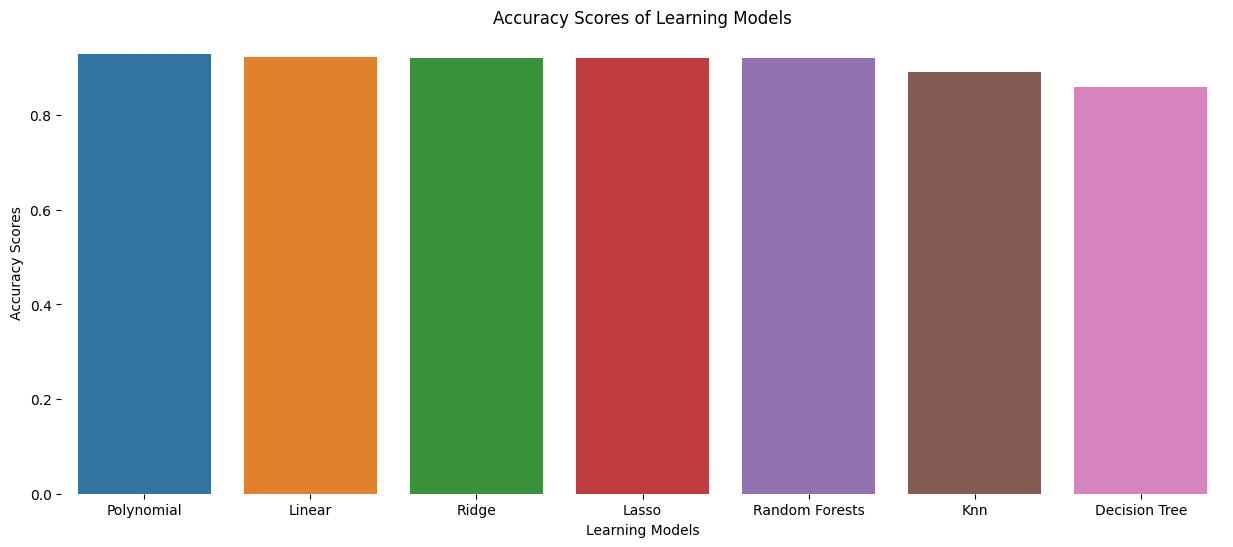

In [ ]:
f, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x='Learning Models', y="Accuracy Scores", data=df_accuracy).set(title='Accuracy Scores of Learning Models')
sns.despine(left=True, bottom=True)

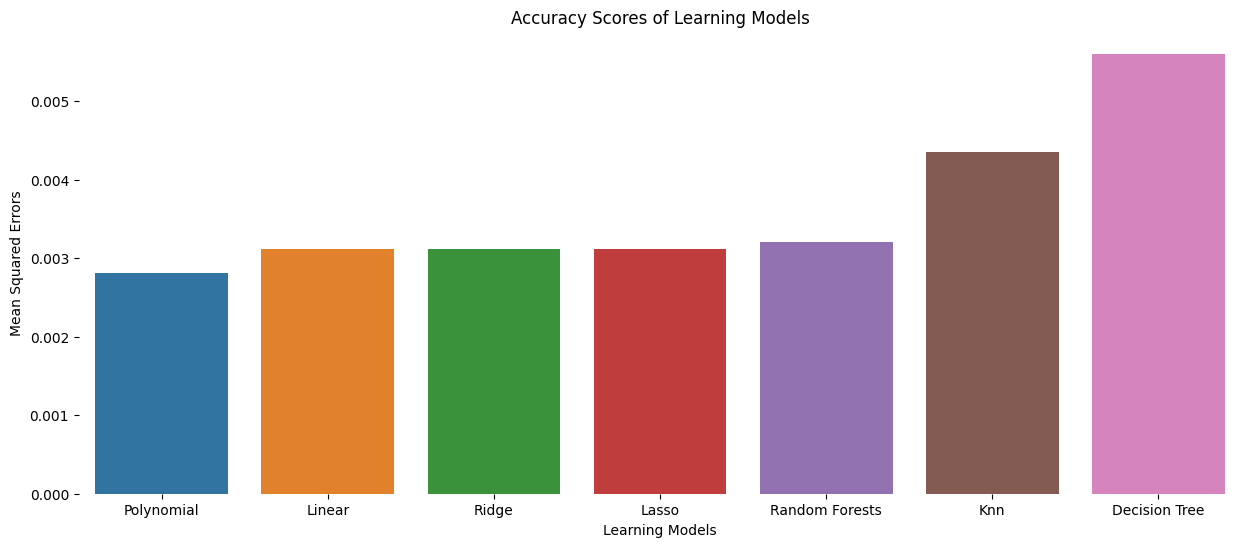

In [ ]:
f, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x='Learning Models', y="Mean Squared Errors", data=df_mse).set(title='Accuracy Scores of Learning Models')
sns.despine(left=True, bottom=True)